In [ ]:
import os

os .environ ['US_TIGER_SHAPEFILE_PATH']='/Users/aaronspaulding/Documents/PycharmProjects/outagescraping/TIGER/tl_2020_us_county/tl_2020_us_county.shp'
os .environ ['CANADA_CENSUS_DIVISIONS_PATH']='/Users/aaronspaulding/Documents/PycharmProjects/outagescraping/CanadaBoundaries/lcd_000b21a_e/lcd_000b21a_e.shp'
os .environ ['DATA_CACHE_PATH']='/Users/aaronspaulding/Documents/PycharmProjects/research_summer_2025/data_cache/'


In [10]:
from research_spring_2025 import get_selected_regions
from research_spring_2025 import generate_h3_grid_from_gdf
from research_spring_2025 import get_parent_cells

counties =get_selected_regions ()
h3_cells =generate_h3_grid_from_gdf (counties ,use_cached_file =True )


In [11]:
from pathlib import Path
import pandas as pd

data_cache_path =Path (os .environ .get ('DATA_CACHE_PATH'))

static_variables_county_path =data_cache_path /'static_variables_fips_and_census.feather'
static_variables_county =pd .read_feather (static_variables_county_path )

h3_cells_with_county =h3_cells .merge (static_variables_county ,on ='index',how ='left')
ct_idx =h3_cells_with_county ['STATEFP']=='09'


In [12]:
unique_parents =get_parent_cells (h3_cells )


In [13]:
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

from shapely .geometry import Polygon

import h3
import h3pandas

from tqdm import tqdm


# Get Road Data For Each Cell


In [14]:
os .environ ['OSMIUM_POOL_THREADS']='24'


In [15]:
base_osm_path ='/Volumes/Lukewarm Cache/osm/'
output_directory ='/Volumes/Hot Cache/osm_trimmed_to_h3_cells/'


In [16]:
def extract_region (input_pbf ,output_pbf ,bbox ):
    cmd =[
    'osmium','extract',
    '--overwrite',
    '-b',f'{bbox[1]},{bbox[0]},{bbox[3]},{bbox[2]}',
    '-o',output_pbf ,
    input_pbf
    ]
    subprocess .run (cmd ,check =True )

input_files ={
'2024':'north-america-240101.osm.pbf',
'2014':'north-america-140101.osm.pbf',
'2015':'north-america-150101.osm.pbf',
'2016':'north-america-160101.osm.pbf',
'2017':'north-america-170101-internal.osm.pbf',
'2018':'north-america-180101.osm.pbf',
'2019':'north-america-190101.osm.pbf',
'2020':'north-america-200101.osm.pbf',
'2021':'north-america-210101.osm.pbf',
'2022':'north-america-220101.osm.pbf',
'2023':'north-america-230101.osm.pbf',
'2025':'north-america-250621.osm.pbf',
}

output_directory =Path (output_directory )
output_directory .mkdir (parents =True ,exist_ok =True )

BUFFER =0.001


In [17]:
def extract_region (input_pbf ,output_pbf ,bbox ):
    cmd =[
    'osmium','extract',
    '--overwrite',
    '-b',f'{bbox[1]},{bbox[0]},{bbox[3]},{bbox[2]}',
    '-o',output_pbf ,
    input_pbf
    ]
    subprocess .run (cmd ,check =True )

for year ,input_pbf in input_files .items ():
    unique_parents_ =unique_parents .copy ()
    unique_parents_ .sort ()
    unique_parents_ =unique_parents_ [::-1 ]

    for parent_cell in tqdm (unique_parents_ ):
        output_pbf =output_directory /f'{year}_{parent_cell}.pbf'

        if output_pbf .exists ():
            continue

        polygon =Polygon (h3 .cell_to_boundary (parent_cell ))
        minx ,miny ,maxx ,maxy =polygon .bounds
        bbox =[minx -BUFFER ,miny -BUFFER ,maxx +BUFFER ,maxy +BUFFER ]

        try :

            extract_region (base_osm_path +input_pbf ,str (output_pbf ),bbox )
        except subprocess .CalledProcessError as e :
            pass


100%|██████████| 1762/1762 [00:00<00:00, 98982.95it/s]


## Now calculate the length of roads for each cell


In [18]:
import osmium
from shapely import LineString


In [19]:
tags_to_keep =['motorway','trunk','primary','secondary','tertiary','residential','unclassified']


In [20]:
class RoadCollector (osmium .SimpleHandler ):
    def __init__ (self ):
        super ().__init__ ()
        self .roads =[]

        self .valid_highways ={
        'motorway','trunk','primary','secondary','tertiary',
        'unclassified','residential','motorway_link',
        'trunk_link','primary_link','secondary_link','tertiary_link'
        }

    def way (self ,w ):
        tags =w .tags
        highway =tags .get ('highway')

        if highway not in self .valid_highways :
            return

        try :
            coords =[(n .lon ,n .lat )for n in w .nodes ]
            if len (coords )>1 :
                line =LineString (coords )
                if line .is_valid and not line .is_empty :
                    self .roads .append (line )
        except Exception :

            pass


In [21]:
h3_cells


,index,geometry,parents
0,8826490001fffff,"POLYGON ((-87.07959 34.95023, -87.07462 34.952...",8426491ffffffff
1,8826490003fffff,"POLYGON ((-87.07492 34.94263, -87.06994 34.944...",8426491ffffffff
2,8826490005fffff,"POLYGON ((-87.08939 34.95088, -87.08441 34.952...",8426491ffffffff
3,8826490007fffff,"POLYGON ((-87.08472 34.94329, -87.07974 34.945...",8426491ffffffff
4,8826490009fffff,"POLYGON ((-87.07446 34.95716, -87.06949 34.959...",8426491ffffffff
...,...,...,...
3571567,884cee7b65fffff,"POLYGON ((-66.11811 18.44039, -66.11475 18.443...",844cee7ffffffff
3571568,884cee7b67fffff,"POLYGON ((-66.11361 18.4356, -66.11025 18.4386...",844cee7ffffffff
3571569,884cee7b69fffff,"POLYGON ((-66.10804 18.44952, -66.10468 18.452...",844cee7ffffffff
3571570,884cee7b6bfffff,"POLYGON ((-66.10353 18.44473, -66.10017 18.447...",844cee7ffffffff


In [19]:
for year in ['2024',]:
    print (f'Extracting {year}...')
    h3_cells [f'length_of_roads_{year}']=-1.

    if f'length_of_roads_{year}'in h3_cells .columns :
        continue

    for parent_cell in tqdm (unique_parents ):
        parent_pbf_file =output_directory /f'{year}_{parent_cell}.pbf'

        try :
            handler =RoadCollector ()
            handler .apply_file (str (parent_pbf_file ),locations =True )
            roads_gdf =gpd .GeoDataFrame (geometry =handler .roads ,crs ='EPSG:4326')

            cells_ =h3_cells [h3_cells ['parents']==parent_cell ]

            for i ,cell__ in cells_ .iterrows ():
                try :
                    clipped_roads =gpd .clip (roads_gdf ,cell__ ['geometry'])
                    clipped_roads =clipped_roads .to_crs ('EPSG:6933')
                    length =clipped_roads .length .sum ()
                except :
                    length =0

                h3_cells .loc [i ,f'length_of_roads_{year}']=length
        except RuntimeError :

            pass


Extracting 2024...
Extracting 2014...
Extracting 2015...
Extracting 2016...
Extracting 2017...
Extracting 2018...
Extracting 2019...
Extracting 2020...
Extracting 2021...
Extracting 2022...
Extracting 2023...
Extracting 2025...


In [15]:
h3_cells .drop (columns =['geometry','parents']).reset_index (drop =True ).to_feather ('/Users/aaronspaulding/Documents/PycharmProjects/research_summer_2025/data_cache/static_variables_length_of_roads.feather')


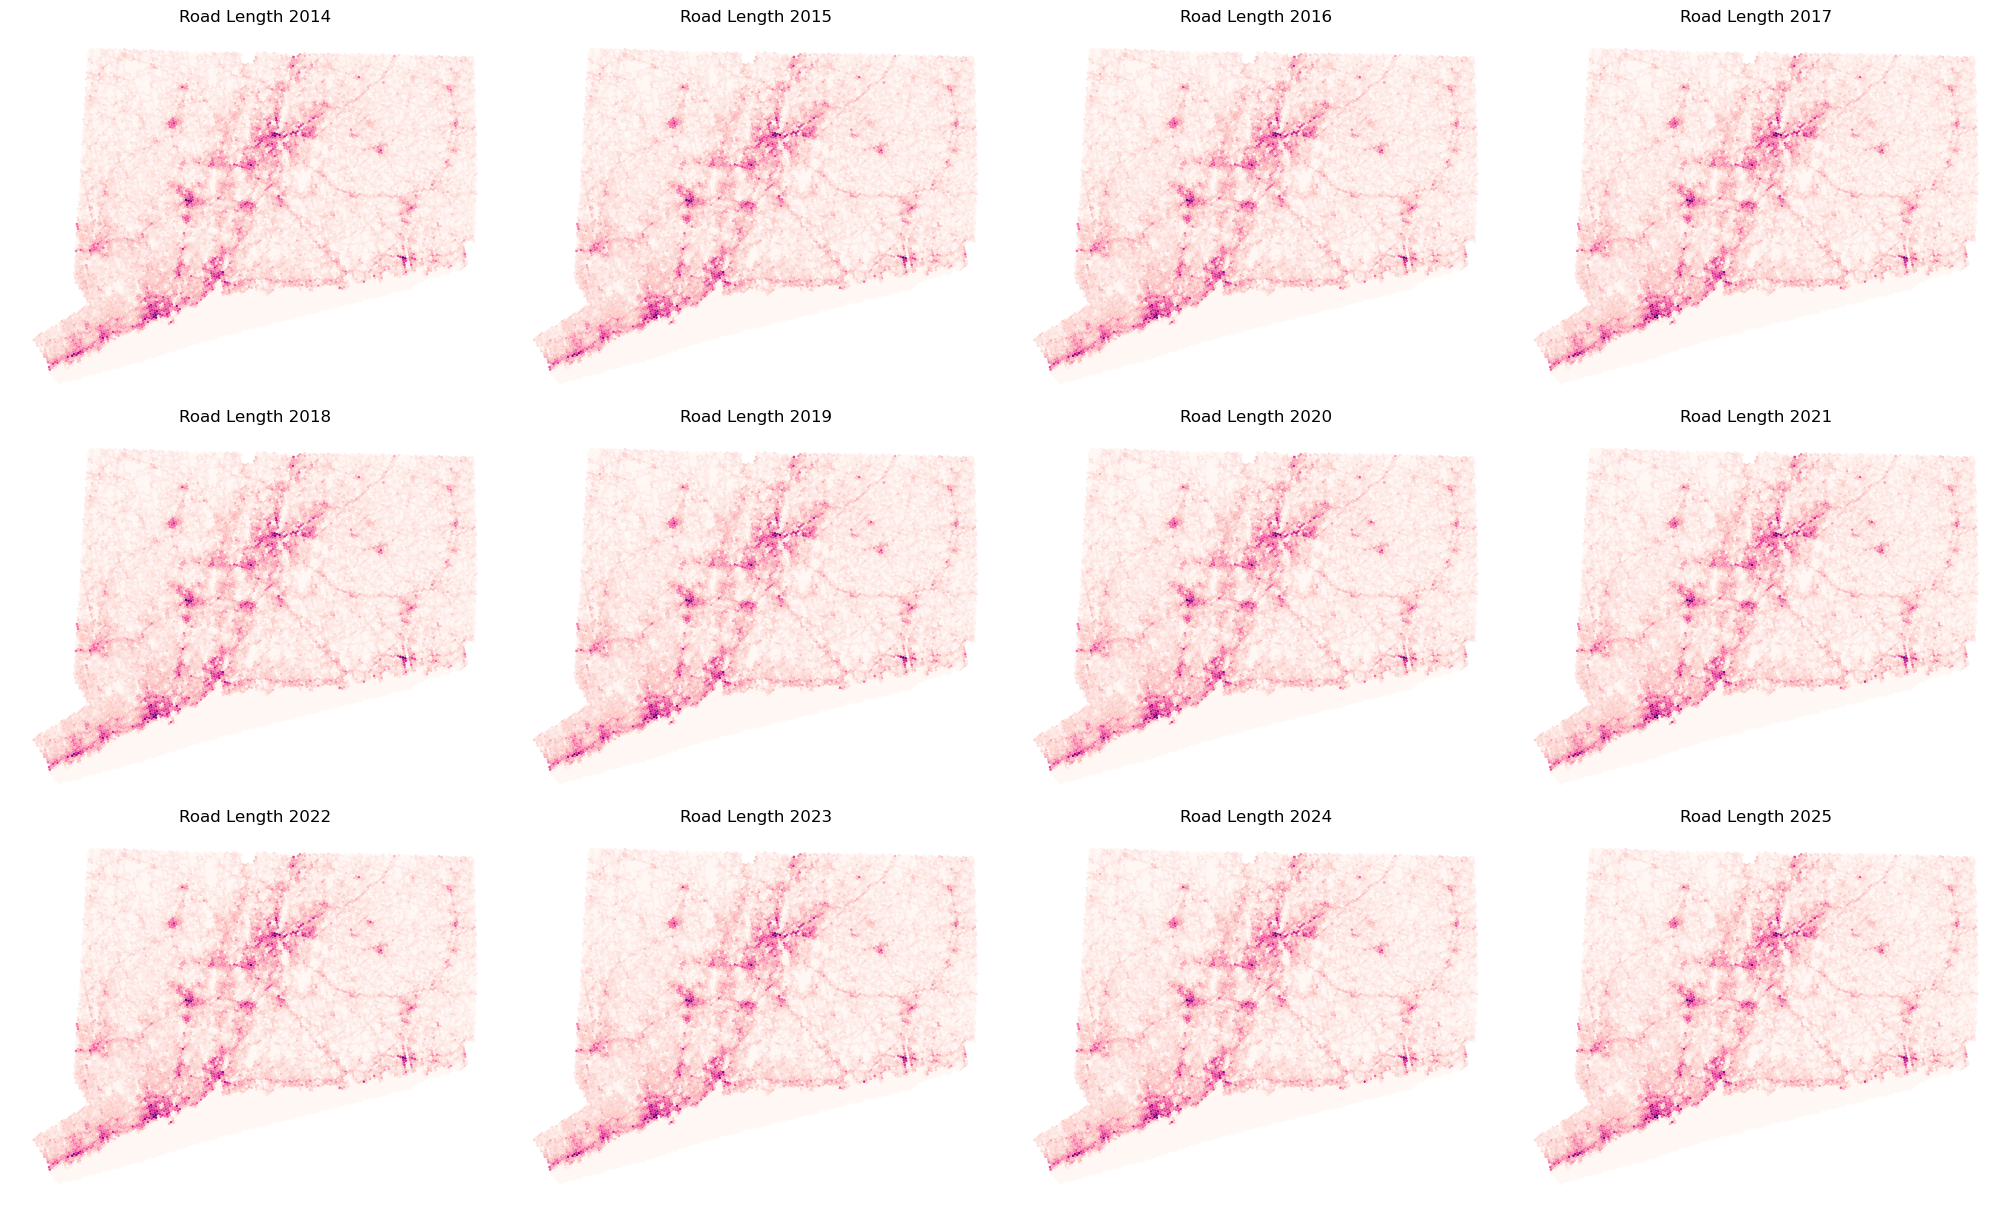

In [71]:
from matplotlib .colors import LogNorm
import matplotlib .pyplot as plt

years =[str (y )for y in range (2014 ,2026 )]

fig ,axes =plt .subplots (3 ,4 ,figsize =(20 ,12 ),constrained_layout =True )

axes =axes .flatten ()

vmax =h3_cells [[f'length_of_roads_{y}'for y in years ]].max ().max ()

for ax ,year in zip (axes ,years ):
    column =f'length_of_roads_{year}'
    data =h3_cells .copy ()

    data .plot (
    ax =ax ,
    column =column ,
    cmap ='RdPu',
    linewidth =0 ,
    vmin =0 ,
    vmax =vmax ,
    edgecolor ='none'
    )

    ax .set_title (f'Road Length {year}',fontsize =12 )
    ax .axis ('off')

for ax in axes [len (years ):]:
    ax .axis ('off')

plt .show ()
